# Importing Libraries

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset

In [21]:
data = pd.read_csv('Preprocessed_dataset.csv')
data.head()

/var/folders/lz/gg3608196pgcm29rnqq45xtm0000gn/T/ipykernel_87568/2152466693.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('Preprocessed_dataset.csv')


,Reporting Period,Project ID,Project County,Project City,Project ZIP,Gas Utility,Electric Utility,Project Completion Date,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,...,Job Type,Type Of Dwelling,Measure Type,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,Year_Home_built_missing_flag,size_of_home_flag,Location_1_latitude,Location_1_Longitude
0,2023-06-30,577366,Broome,Endicott,13760,New York State Electric & Gas,New York State Electric & Gas,2023-06-22,9661.0,Oil,...,Home Performance,Single Family,Building Shell,277.0,24.0,6.826545,2,0,42.110115,-76.032545
1,2023-06-30,581070,Queens,Queens,11433,National Grid,Consolidated Edison,2023-06-22,11867.0,Natural Gas,...,Home Performance,Single Family,Building Shell,1062.0,66.0,7.221105,2,0,40.697715,-73.786045
2,2023-06-30,570945,Oswego,Fulton,13069,National Grid,National Grid,2023-06-20,9998.0,Natural Gas,...,Home Performance,Single Family,Building Shell,59.0,60.0,6.489205,2,0,43.325035,-76.41174
3,2023-06-30,571921,St. Lawrence,Nicholville,12965,Saint Lawrence Gas,National Grid,2023-06-13,6880.0,Oil,...,Home Performance,Single Family,Building Shell,482.0,15.0,6.445720,2,0,44.695165,-74.704765
4,2023-06-30,555646,Oswego,Cleveland,13042,National Grid,National Grid,2023-06-13,12289.0,Oil,...,Home Performance,Single Family,Building Shell,690.0,78.0,7.490529,2,0,43.2312547,-75.8681922


In [22]:
data.shape

(51934, 23)

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51934 entries, 0 to 51933
Data columns (total 23 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Reporting Period                                      51934 non-null  object 
 1   Project ID                                            51934 non-null  object 
 2   Project County                                        51934 non-null  object 
 3   Project City                                          51934 non-null  object 
 4   Project ZIP                                           51934 non-null  int64  
 5   Gas Utility                                           51934 non-null  object 
 6   Electric Utility                                      51934 non-null  object 
 7   Project Completion Date                               51934 non-null  object 
 8   Total Project Cost                                    51

In [24]:
data.describe()

,Project ZIP,Total Project Cost,Year Home Built,Size Of Home,Number Of Units,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,Year_Home_built_missing_flag,size_of_home_flag
count,51934.000000,51934.000000,51934.000000,51934.000000,51934.000000,51934.000000,51934.000000,51930.000000,51934.000000,51934.0
mean,13263.577695,6432.440848,1953.205723,1572.731717,1.058074,469.881330,31.389013,5.853971,1.200350,0.0
std,1300.423594,4154.131692,23.418304,627.668989,2.175599,1095.349244,27.025809,0.875141,0.979409,0.0
min,10001.000000,129.000000,1800.000000,800.000000,1.000000,-23368.000000,-80.000000,0.000000,0.000000,0.0
25%,12458.000000,3742.000000,1955.000000,1111.000000,1.000000,158.000000,14.000000,5.356586,0.000000,0.0
50%,13492.000000,5926.000000,1955.000000,1440.000000,1.000000,443.000000,26.000000,5.957131,2.000000,0.0
75%,14424.000000,8462.000000,1955.000000,1874.000000,1.000000,536.000000,43.000000,6.444131,2.000000,0.0
max,14905.000000,92297.000000,2022.000000,4000.000000,396.000000,38572.000000,1005.000000,10.199547,2.000000,0.0


# EDA

## Univariate Analysis

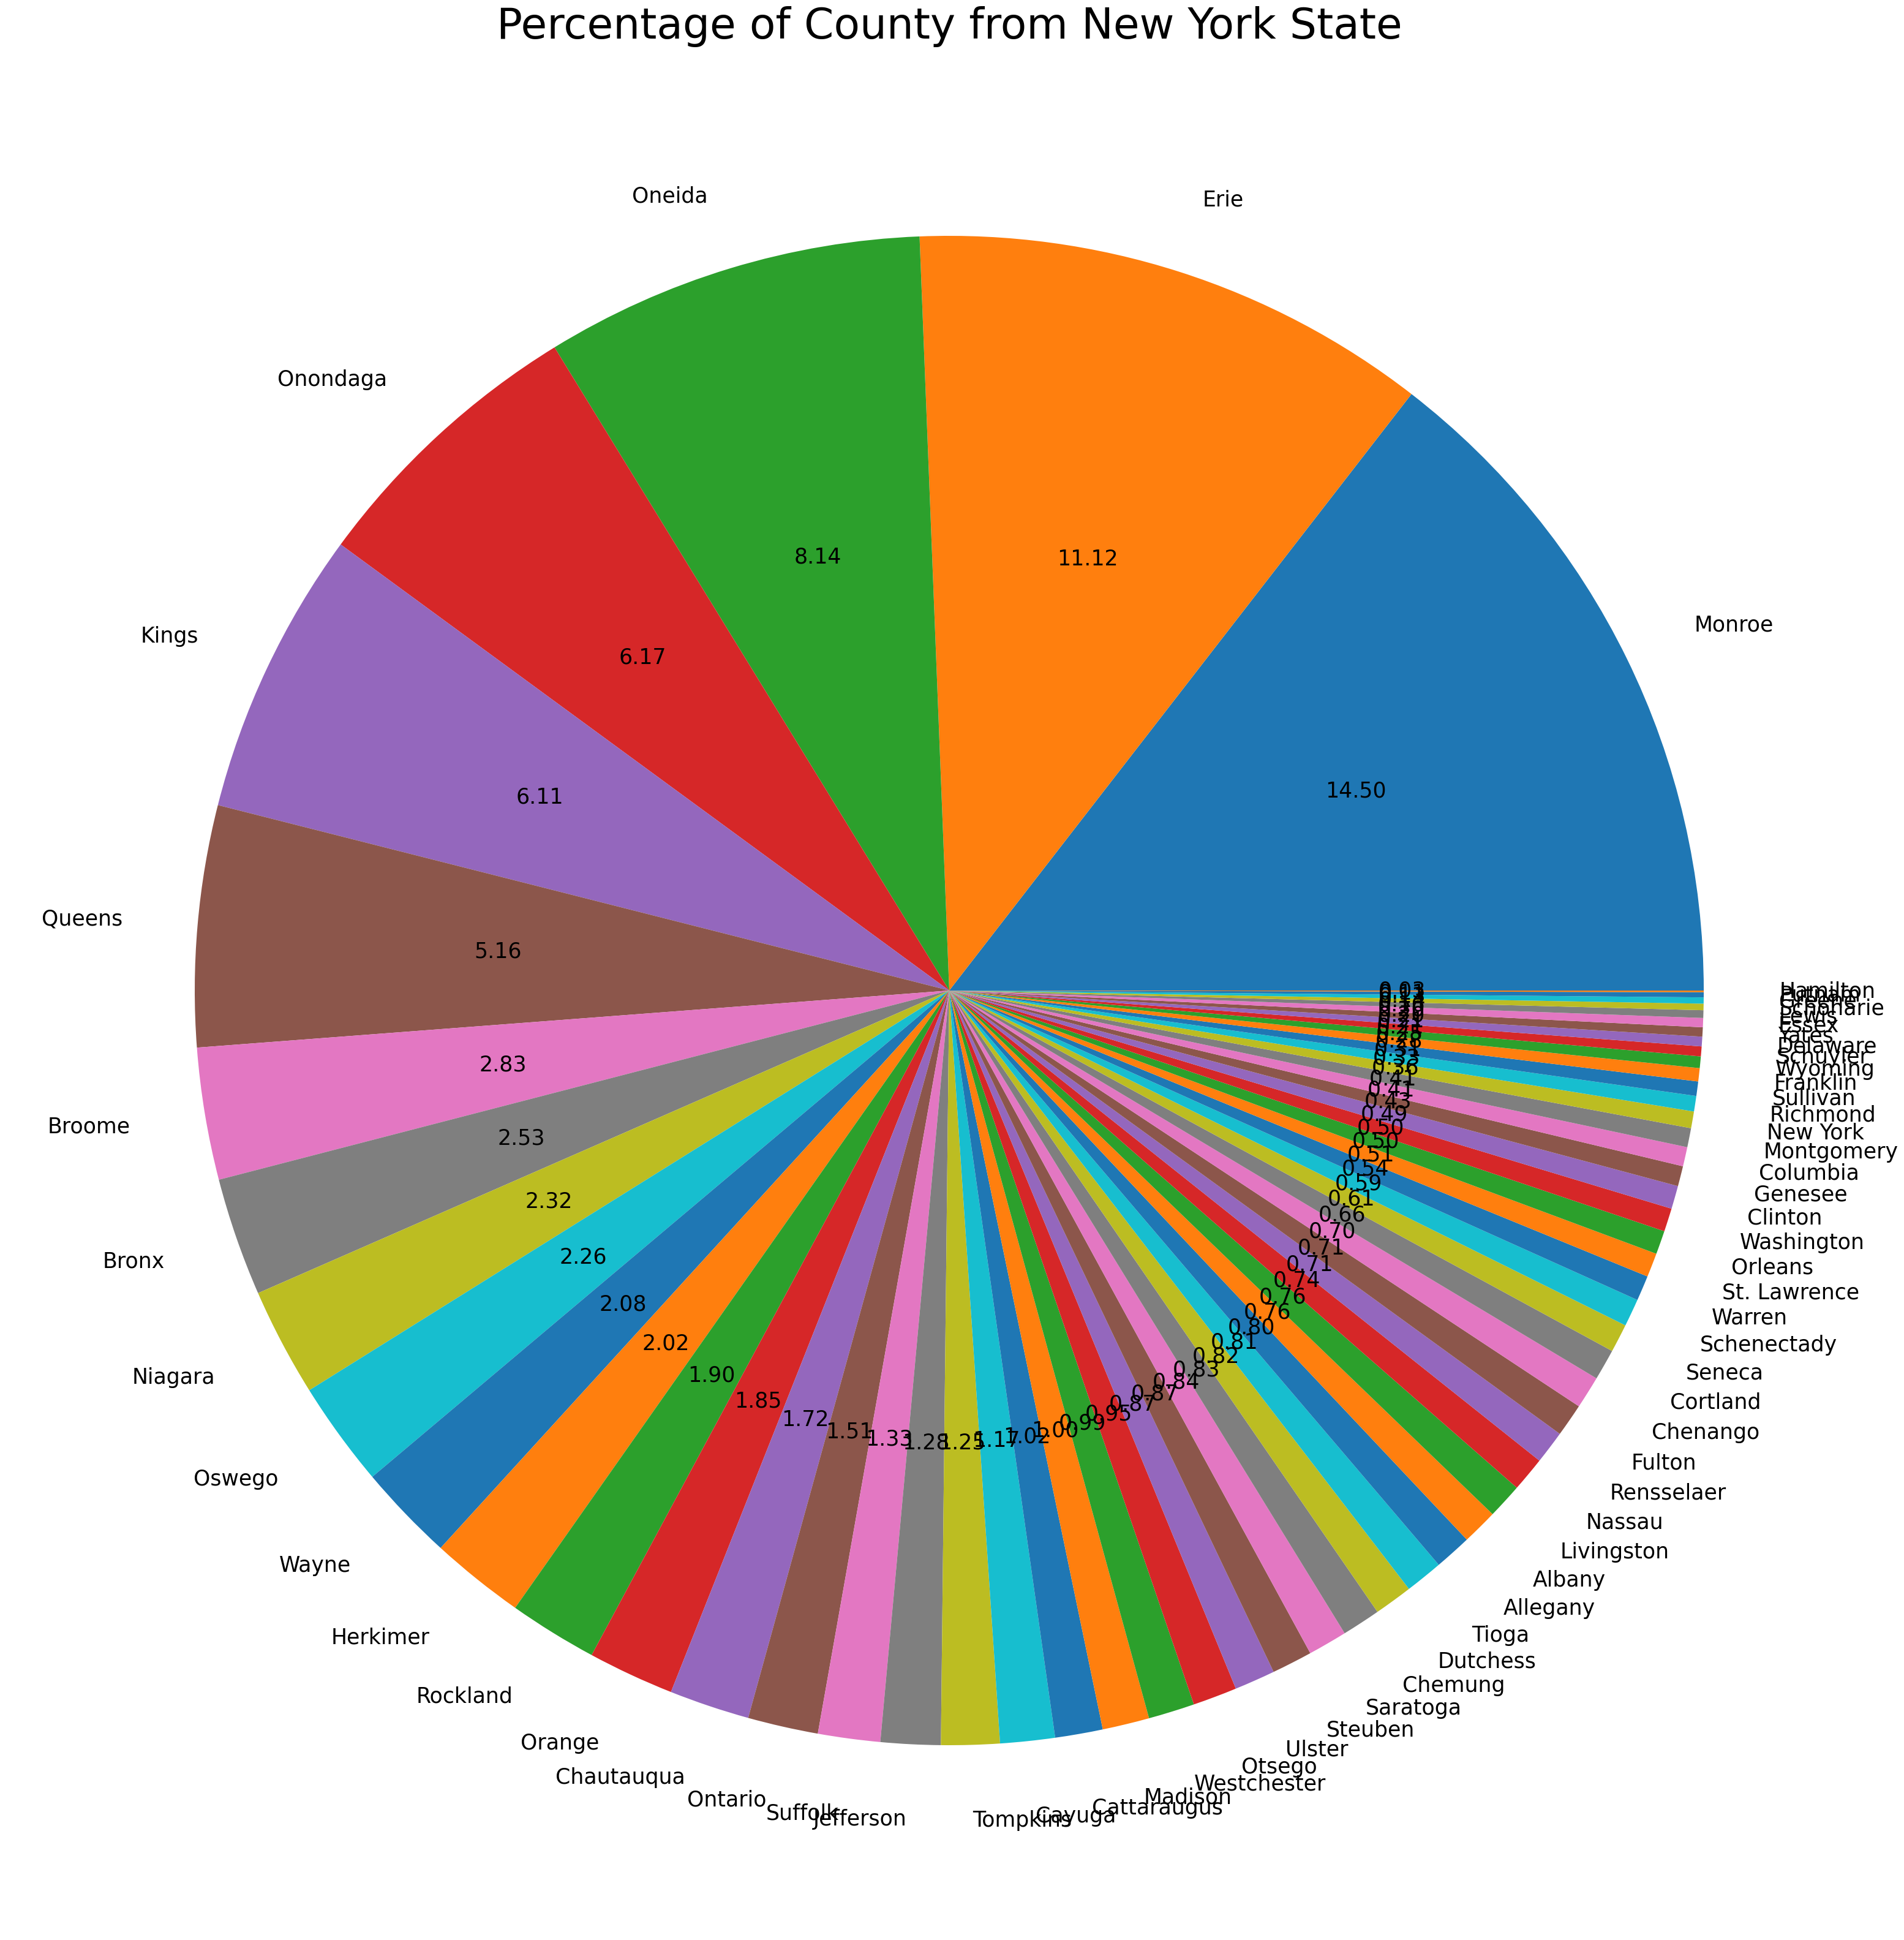

In [28]:
county_count = data['Project County'].value_counts()
plt.figure(figsize=(40,40))
plt.pie(county_count, labels= county_count.index, autopct= "%.2f", textprops={'fontsize': 25})
plt.title("Percentage of County from New York State", fontsize = "50")
plt.xticks(rotation =45)
plt.show()

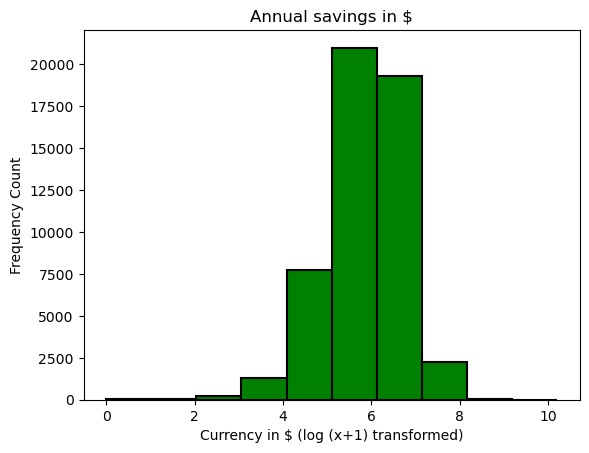

In [31]:
plt.hist(data['First Year Modeled Project Energy Savings $ Estimate'], color="green" , edgecolor='black', linewidth=1.5)
plt.title("Annual savings in $")
plt.xlabel("Currency in $ (log (x+1) transformed)")
plt.ylabel("Frequency Count")

plt.show()

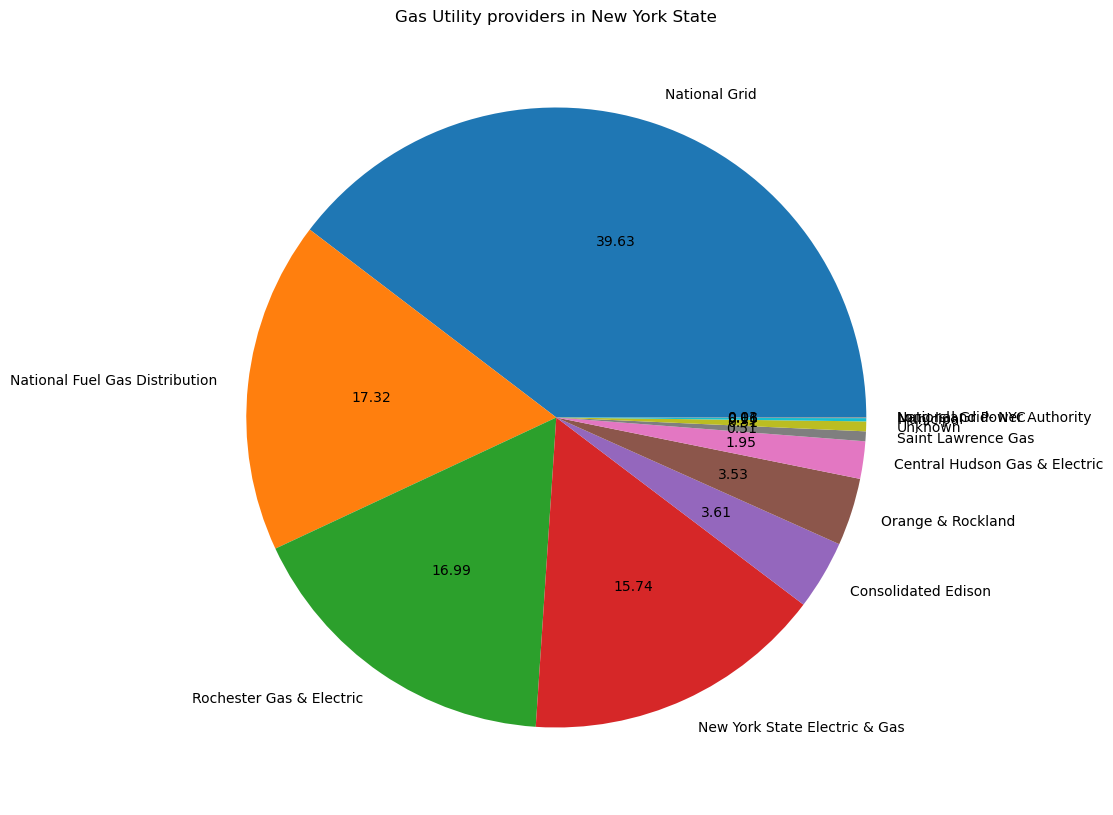

In [ ]:
gau_utils = data['Gas Utility'].value_counts()

plt.figure(figsize=(10,30))
plt.pie(gau_utils, labels=gau_utils.index, autopct="%.2f")
plt.title("Gas Utility providers in New York State")
plt.show()

In [37]:
data['Gas Utility'].value_counts()

Gas Utility
National Grid                     20584
National Fuel Gas Distribution     8993
Rochester Gas & Electric           8825
New York State Electric & Gas      8176
Consolidated Edison                1877
Orange & Rockland                  1831
Central Hudson Gas & Electric      1012
Saint Lawrence Gas                  266
Unknown                             266
Municipal                            85
Long Island Power Authority          13
National Grid- NYC                    6
Name: count, dtype: int64

In [51]:
gas = data[data['Electric Utility']=="Municipal"].groupby(["Project County", "Electric Utility","Gas Utility"])['Project ID'].count()
print(gas)

Project County  Electric Utility  Gas Utility                   
Albany          Municipal         National Grid                       2
Allegany        Municipal         Municipal                           1
                                  National Fuel Gas Distribution     43
Broome          Municipal         New York State Electric & Gas      14
Cattaraugus     Municipal         Municipal                           2
                                  National Fuel Gas Distribution     39
                                  New York State Electric & Gas       1
Chautauqua      Municipal         Municipal                           7
                                  National Fuel Gas Distribution    253
                                  National Grid                       2
Chenango        Municipal         Unknown                            14
Clinton         Municipal         Municipal                           6
                                  New York State Electric & Gas       1

##### Findings 1
 The Gas Utility still has unknown entity has we are unable to create a relationship using our pipeline county->electric utility -> mode(Gas utility) for specific counties

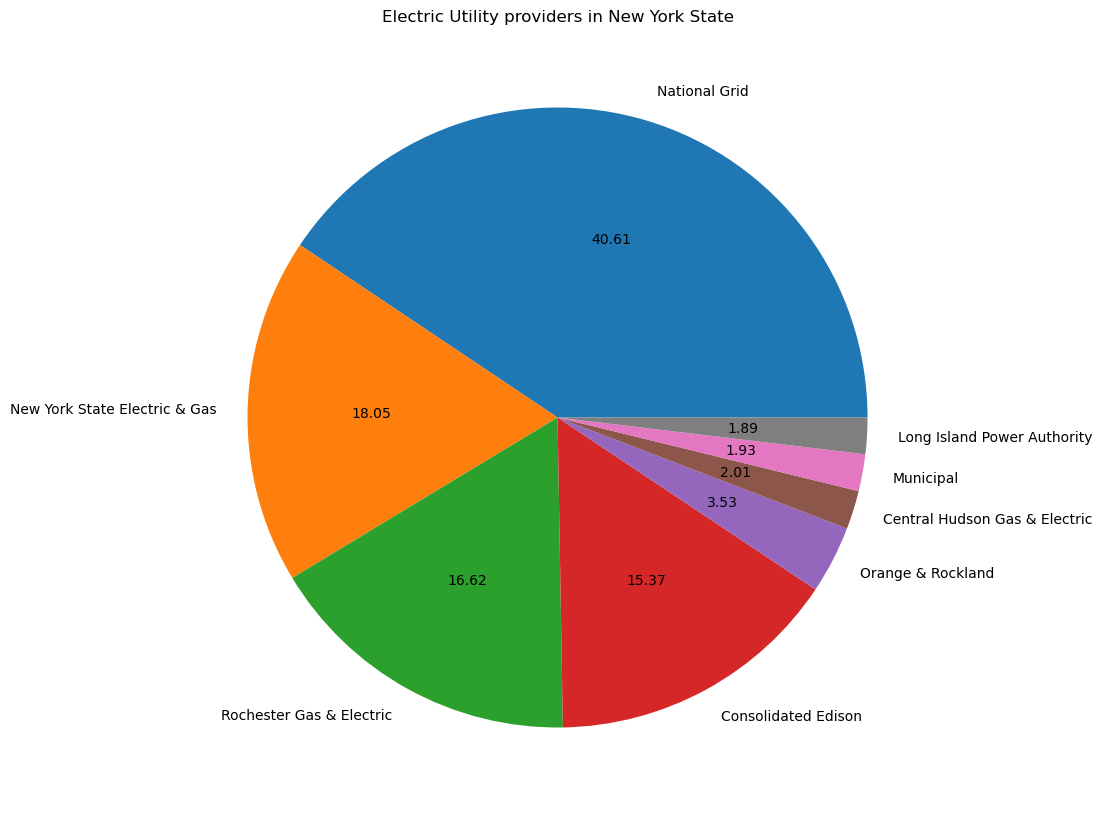

In [53]:
elec_utils = data['Electric Utility'].value_counts()

plt.figure(figsize=(10,30))
plt.pie(elec_utils, labels=elec_utils.index, autopct="%.2f")
plt.title("Electric Utility providers in New York State")
plt.show()

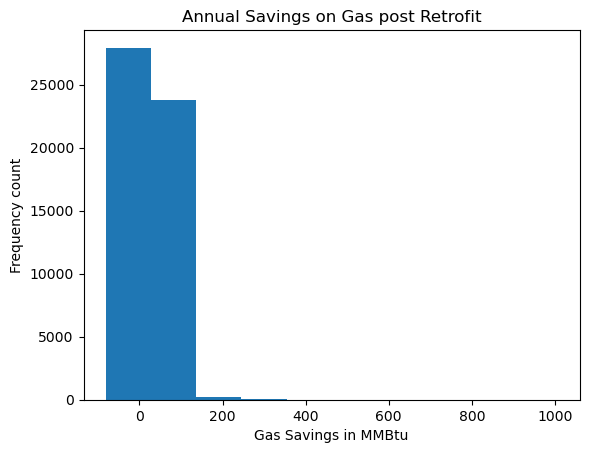

In [54]:
plt.hist(data['Estimated Annual MMBtu Savings'])
plt.title("Annual Savings on Gas post Retrofit")
plt.xlabel("Gas Savings in MMBtu")
plt.ylabel("Frequency count")
plt.show()

### Findings 2

The Estimated Annual MMBtu Savings is left skewed with long right tail, which tells that any large value which dominate the loss function, we perform log(x+1) transformation to assume that the data points are normal distributed which would result more reliable and stable for the model

### *Need to work on this*

can not apply log transformation as there are negative savings, need to transform in a way where we can normal distribute the data

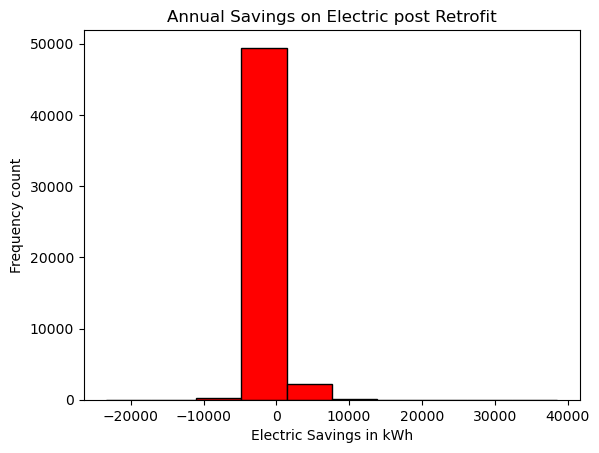

In [63]:
plt.hist(data['Estimated Annual kWh Savings'], color  ="red", edgecolor ="black")
plt.title("Annual Savings on Electric post Retrofit")
plt.xlabel("Electric Savings in kWh")
plt.ylabel("Frequency count")
plt.show()

In [64]:
from scipy.stats import skew, kurtosis

col = data['Estimated Annual kWh Savings']

print("Skewness:", skew(col, nan_policy='omit'))
print("Kurtosis:", kurtosis(col, nan_policy='omit'))

Skewness: 4.7923468379033505
Kurtosis: 194.62456740041299


### Findings 3
the value is skewed, the graph has a sharp rise at close to zero and have no proper distribution around it which larger values expanding the axis

### *Need to work on the above skewness*

In [67]:
def hist_plot(x):
    title = x
    plt.figure(figsize=(20,20))
    plt.hist(data[x], edgecolor ="black", bins = 10)
    plt.title(f"The distribution plot of {title}")
    plt.show()

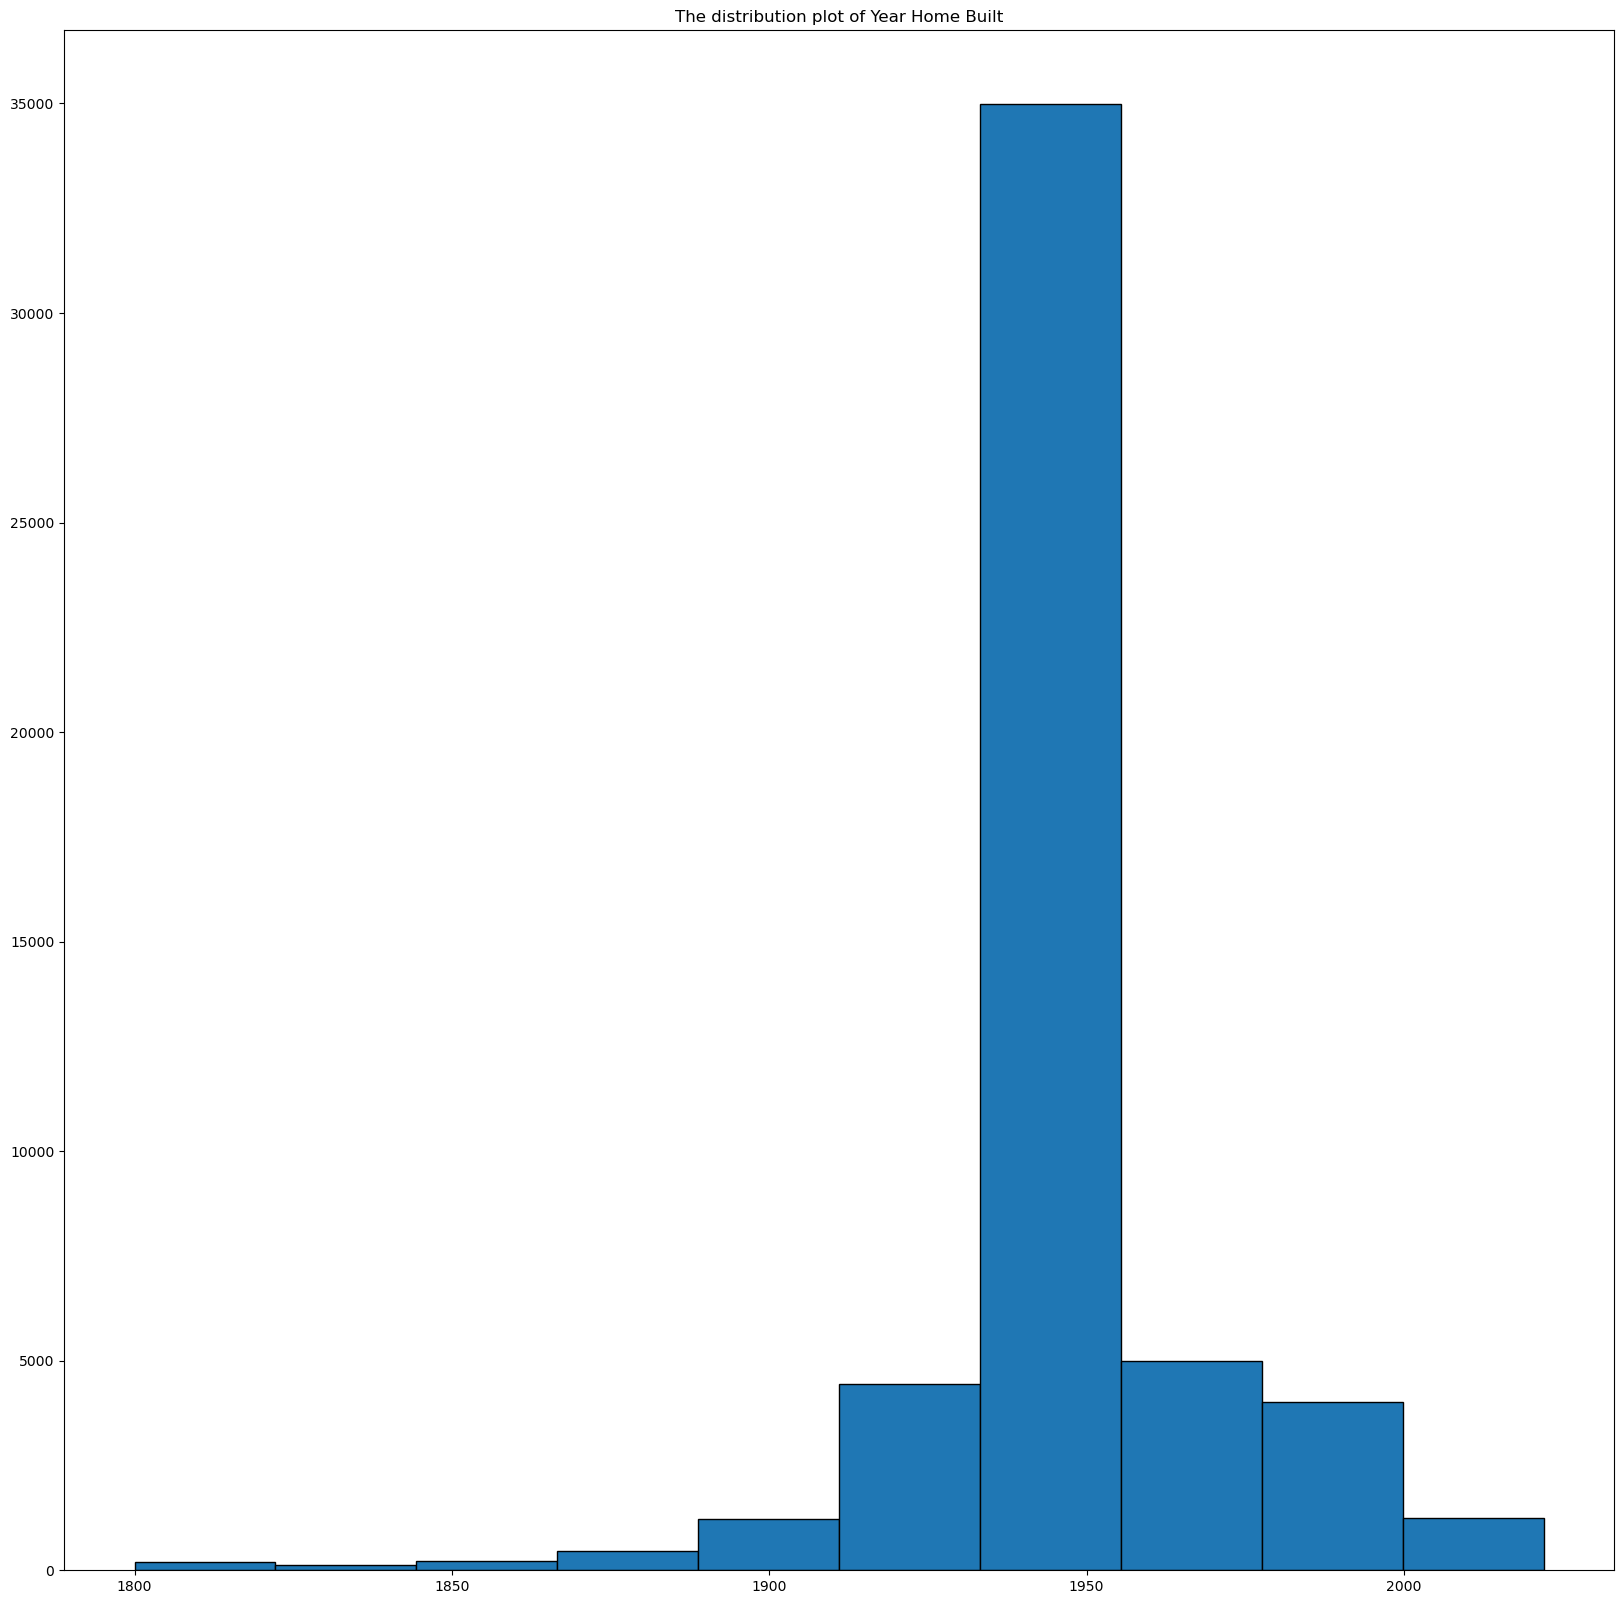

In [68]:
hist_plot("Year Home Built")

### Finding 5
The data shows that the predominant house which are part of the retrofit program are built between 1900 and 2000

## Bivariate Analysis

In [69]:
def bar_plot(x,y):
    data_x = x
    data_y = y
    plt.figure(figsize=(10,10))
    plt.bar(data[data_x], data[data_y])
    plt.title(f" {data_x} v/s {data_y}")
    plt.xlabel(f"{data_x}")
    plt.ylabel(f"{data_y}")
    plt.show()

In [70]:
data.columns

Index(['Reporting Period', 'Project ID', 'Project County', 'Project City',
       'Project ZIP', 'Gas Utility', 'Electric Utility',
       'Project Completion Date', 'Total Project Cost',
       'Pre-Retrofit Home Heating Fuel Type', 'Year Home Built',
       'Size Of Home', 'Number Of Units', 'Job Type', 'Type Of Dwelling',
       'Measure Type', 'Estimated Annual kWh Savings',
       'Estimated Annual MMBtu Savings',
       'First Year Modeled Project Energy Savings $ Estimate',
       'Year_Home_built_missing_flag', 'size_of_home_flag',
       'Location_1_latitude', 'Location_1_Longitude'],
      dtype='object')

Text(0.5, 0, 'Project cost')

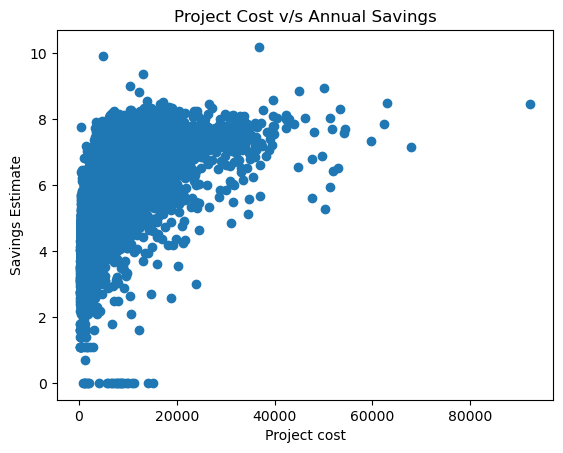

In [75]:
plt.scatter(data['Total Project Cost'], data['First Year Modeled Project Energy Savings $ Estimate'])
plt.title("Project Cost v/s Annual Savings")
plt.ylabel("Savings Estimate")
plt.xlabel("Project cost")